<a href="https://colab.research.google.com/github/azvicer-a11y/DSB-Unit-02/blob/main/AnjaLabs/lab-eda-titanic/lab-eda-titanic-student-submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/azvicer-a11y/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv"

titanic_df = pd.read_csv(url)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: title={'center': 'Missing Values by Column'}, xlabel='Columns', ylabel='Number of Missing Values'>

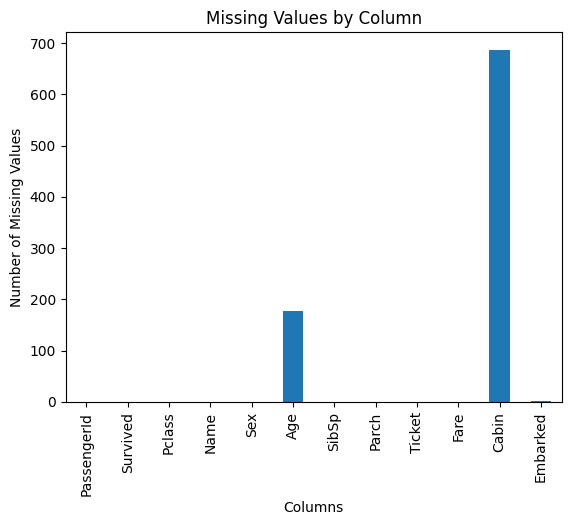

In [ ]:
titanic_df.isnull().sum().plot(
    kind="bar",
    title="Missing Values by Column",
    xlabel="Columns",
    ylabel="Number of Missing Values"
)

In [ ]:
missing_values = titanic_df.isnull().sum()

print("Column with most missing values:", missing_values.idxmax())
print("Number of missing values:", missing_values.max())

Column with most missing values: Cabin
Number of missing values: 687


In [ ]:
titanic_df = titanic_df.dropna(subset=["Embarked"]).copy()

In [ ]:
titanic_df["Cabin"] = titanic_df["Cabin"].fillna("¯\\*(ツ)*/¯")

In [ ]:
titanic_df["Cabin"].isnull().sum()

np.int64(0)

In [ ]:
titanic_df["FamilyCount"] = titanic_df["SibSp"] + titanic_df["Parch"]

In [ ]:
titanic_df[["SibSp", "Parch", "FamilyCount"]].head()

,SibSp,Parch,FamilyCount
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [ ]:
titanic_df["IsReverend"] = titanic_df["Name"].str.contains("Rev.").astype(int)

In [ ]:
titanic_df[["Name", "IsReverend"]].head(20)

,Name,IsReverend
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0
2,"Heikkinen, Miss. Laina",0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0
4,"Allen, Mr. William Henry",0
5,"Moran, Mr. James",0
6,"McCarthy, Mr. Timothy J",0
7,"Palsson, Master. Gosta Leonard",0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0
9,"Nasser, Mrs. Nicholas (Adele Achem)",0


In [ ]:
titanic_df["IsReverend"].value_counts()

,count
IsReverend,
0,883
1,6


In [ ]:
embarked_dummies = pd.get_dummies(
    titanic_df["Embarked"],
    prefix="Embarked",
    dtype=int
)

titanic_df = pd.concat([titanic_df, embarked_dummies], axis=1)

In [ ]:
titanic_df[["Embarked", "Embarked_C", "Embarked_Q", "Embarked_S"]].head(10)

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1
5,Q,0,1,0
6,S,0,0,1
7,S,0,0,1
8,S,0,0,1
9,C,1,0,0


In [ ]:
sex_dummies = pd.get_dummies(
    titanic_df["Sex"],
    prefix="Sex",
    dtype=int
)

titanic_df = pd.concat([titanic_df, sex_dummies], axis=1)

In [ ]:
titanic_df[["Sex", "Sex_female", "Sex_male"]].head(10)

,Sex,Sex_female,Sex_male
0,male,0,1
1,female,1,0
2,female,1,0
3,female,1,0
4,male,0,1
5,male,0,1
6,male,0,1
7,male,0,1
8,female,1,0
9,female,1,0


In [ ]:
overall_survival_rate = titanic_df["Survived"].mean()

overall_survival_rate

np.float64(0.38245219347581555)

In [ ]:
titanic_df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.740385
male,0.188908


In [ ]:
titanic_df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


In [ ]:
titanic_df[titanic_df["IsReverend"] == 1]["Survived"].sum()

np.int64(0)

In [ ]:
titanic_df[titanic_df["Cabin"] == "¯\\*(ツ)*/¯"]["Survived"].mean()

np.float64(0.29985443959243085)

In [ ]:
titanic_df[titanic_df["Age"].isnull()]["Survived"].mean()

np.float64(0.2937853107344633)

In [ ]:
titanic_df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [ ]:
children = titanic_df[titanic_df["Age"] < 12]

children.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.750000
2,1.000000
3,0.404255


In [ ]:
titanic_df[titanic_df["Name"].str.contains("Capt.", regex=False)][
    ["Name", "Survived"]
]

,Name,Survived
745,"Crosby, Capt. Edward Gifford",0


In [12]:
#Of all the people that died, who had the most expensive ticket? How much did it cost?
died = titanic_df[titanic_df["Survived"] == 0]

died.loc[died["Fare"].idxmax(), ["Name", "Fare"]]



,27
Name,"Fortune, Mr. Charles Alexander"
Fare,263.0


In [ ]:
titanic_df.groupby(titanic_df["FamilyCount"] > 0)["Survived"].mean()

,Survived
FamilyCount,
False,0.300935
True,0.505650


In [10]:
#Using matplotlib and seaborn, create several charts showing the survival rates of different groups of people. It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface
import matplotlib.pyplot as plt
import seaborn as sns

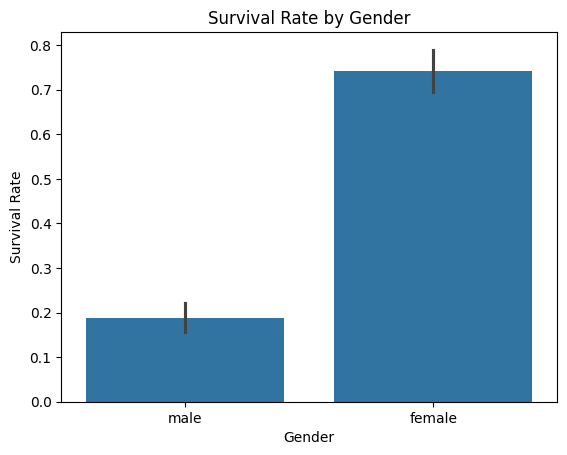

In [11]:
sns.barplot(
    data=titanic_df,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.show()

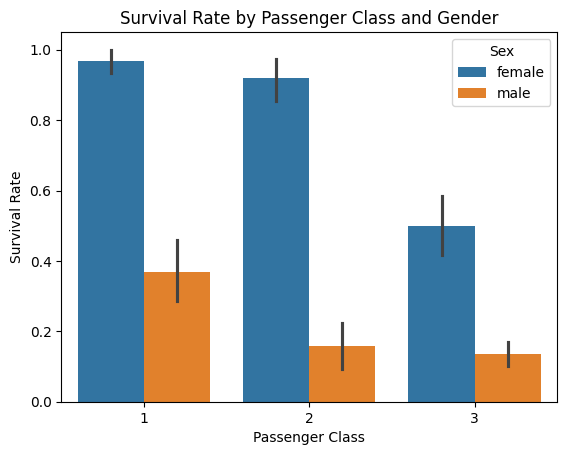

In [ ]:
sns.barplot(
    data=titanic_df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()